**Retail Demand Forecasting**
**Phase 4 – Exploratory Data Analysis**
**Business Objective**
Explore historical sales data to identify patterns, trends, and business drivers influencing retail sales.

**Dataset**
cleaned_data.csv

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

pd.set_option("display.max_columns", None)

plt.style.use("ggplot")

In [4]:
df = pd.read_csv(r"C:\Users\mahip\Desktop\Retail-Demand-Forecasting-Analytics\data\processed\cleaned_data.csv")

df["Date"] = pd.to_datetime(df["Date"])

C:\Users\mahip\AppData\Local\Temp\ipykernel_19312\986038411.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\mahip\Desktop\Retail-Demand-Forecasting-Analytics\data\processed\cleaned_data.csv")


In [5]:
df = pd.read_csv(
    "../data/processed/cleaned_data.csv",
    dtype={
        "StateHoliday": "string",
        "StoreType": "string",
        "Assortment": "string",
        "PromoInterval": "string"
    }
)

df["Date"] = pd.to_datetime(df["Date"])

In [6]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,<NA>
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,0.0,0.0,<NA>
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,0.0,0.0,<NA>


In [7]:
df.shape()

TypeError: 'tuple' object is not callable

In [8]:
df.shape

(1017209, 18)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[ns]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  string        
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  string        
 10  Assortment                 1017209 non-null  string        
 11  CompetitionDistance        1017209 no

**How are sales distributed?**

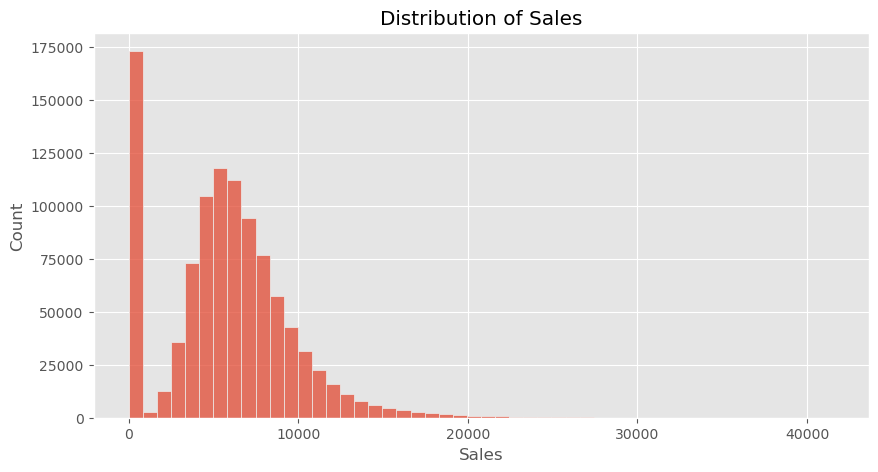

In [13]:
plt.figure(figsize=(10,5))

sns.histplot(df["Sales"], bins=50)

plt.title("Distribution of Sales")

plt.show()

In [11]:
df["Sales"].eq(0).sum()

np.int64(172871)

In [12]:
df[df["Sales"] == 0]["Open"].value_counts()

Open
0    172817
1        54
Name: count, dtype: int64

**Zero Sales Analysis**

**-The dataset contains 172,871 records with zero sales.**
**-Of these, 172,817 (99.97%) correspond to stores that were closed (Open = 0).**
**-Only 54 records have zero sales while the store was open, indicating rare operational or data anomalies.**
**-Since the objective is to forecast sales for operating stores, closed-store records will be excluded during the model-building phase.**

**Sales Statistics**

In [14]:
df["Sales"].describe()

count    1.017209e+06
mean     5.773819e+03
std      3.849926e+03
min      0.000000e+00
25%      3.727000e+03
50%      5.744000e+03
75%      7.856000e+03
max      4.155100e+04
Name: Sales, dtype: float64

**Sales Over Time**

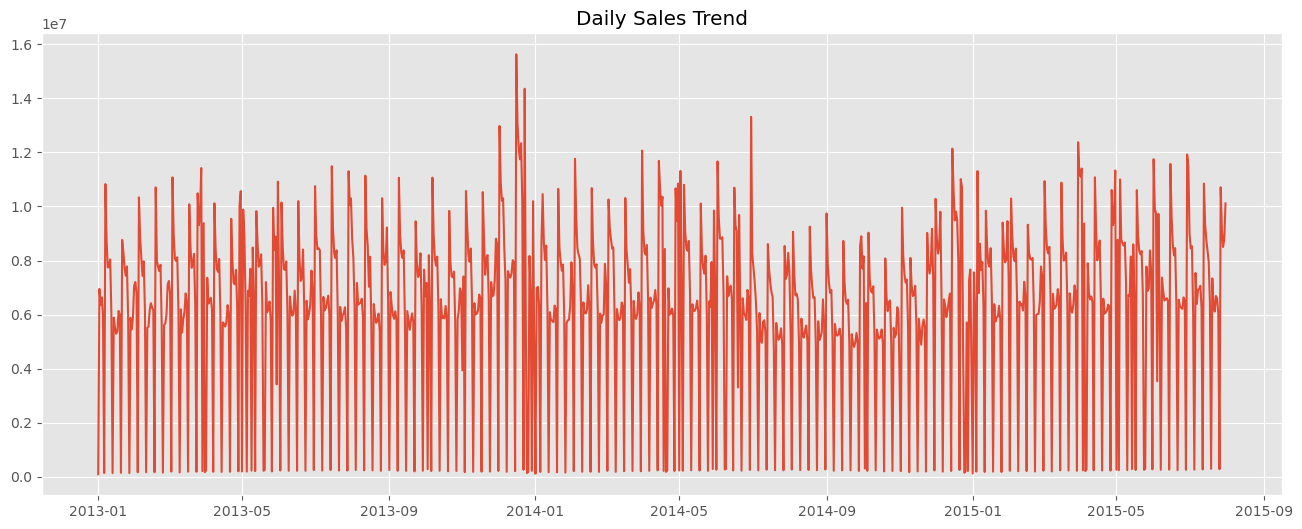

In [15]:
daily_sales = df.groupby("Date")["Sales"].sum().reset_index()

plt.figure(figsize=(16,6))

plt.plot(daily_sales["Date"], daily_sales["Sales"])

plt.title("Daily Sales Trend")

plt.show()

**Monthly Sales Trend**

In [18]:
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year

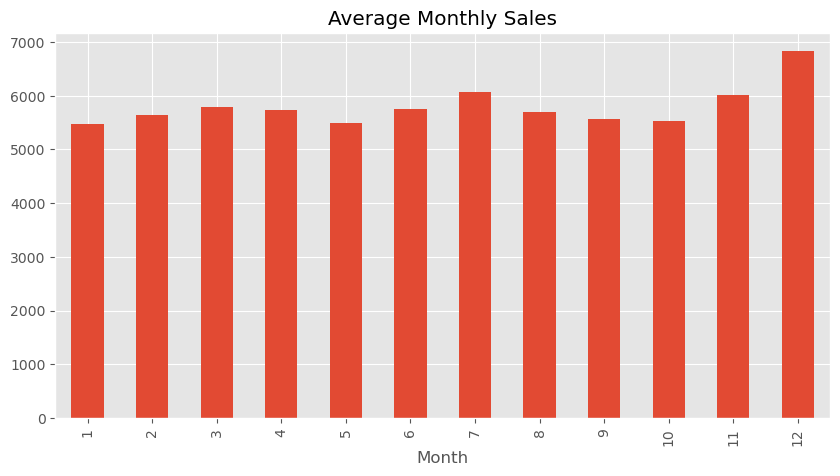

In [20]:
monthly_sales = df.groupby("Month")["Sales"].mean()

monthly_sales.plot(kind="bar", figsize=(10,5))

plt.title("Average Monthly Sales")

plt.show()

**The highest sales recorded at the end of the year**

**Sales by Day of Week**

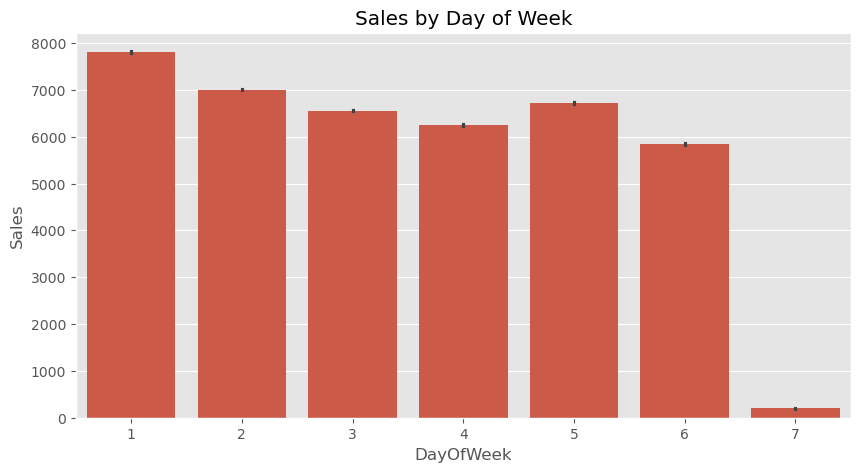

In [23]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="DayOfWeek",
    y="Sales",
    data=df
)

plt.title("Sales by Day of Week")

plt.show()

**Business Interpretation**

The exceptionally low sales on Day 7 are unlikely to indicate poor customer demand. A more likely explanation is that most Rossmann stores are closed on that day, causing the average sales to drop close to zero.

This means that operational schedules, not customer demand, are driving the observed pattern.

In [24]:
df.groupby("DayOfWeek")["Open"].value_counts()

DayOfWeek  Open
1          1       137560
           0         7170
2          1       143961
           0         1703
3          1       141936
           0         3729
4          1       134644
           0        11201
5          1       138640
           0         7205
6          1       144058
           0          672
7          0       141137
           1         3593
Name: count, dtype: int64

**The sales on day 7 is lowest because On Day 7:**

141,137 stores were closed
Only 3,593 stores were open 

**Store Type Analysis**

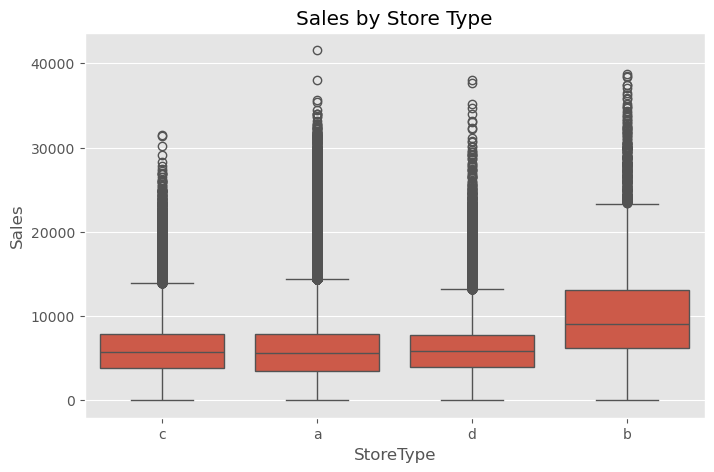

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="StoreType",
    y="Sales",
    data=df
)

plt.title("Sales by Store Type")

plt.show()

**1. Store Type b has the highest sales.

You can see this because:

Highest median
Highest upper quartile
Highest whisker
2. Store Types a, c, and d are fairly similar.

Their medians are all around 5k–6k.

3. Store Type b has greater variability.

Its box is taller.

That means sales fluctuate more compared to other store types.

4. There are many outliers.

Almost every store type has hundreds of outliers.

This indicates some stores or days achieve exceptionally high sales, which is common in retail due to promotions, holidays, or seasonal demand**

**Promotion Impact**

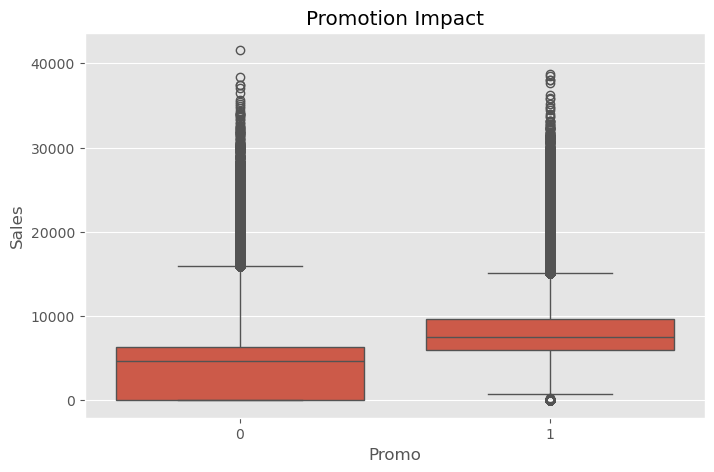

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Promo",
    y="Sales",
    data=df
)

plt.title("Promotion Impact")

plt.show()

In [27]:
df.groupby("Promo")["Sales"].mean()

Promo
0    4406.050805
1    7991.152046
Name: Sales, dtype: float64

**EDA Interpretation**

The box plot indicates that promotions are associated with higher sales. Stores with active promotions (Promo = 1) have a noticeably higher median sales value and higher quartiles compared to stores without promotions. The non-promotion group contains many zero-sales observations, likely corresponding to closed stores, which lowers its overall distribution. Both groups exhibit several high-value outliers, reflecting occasional exceptionally strong sales days. Overall, promotions appear to positively influence store sales.

**Customer Analysis**

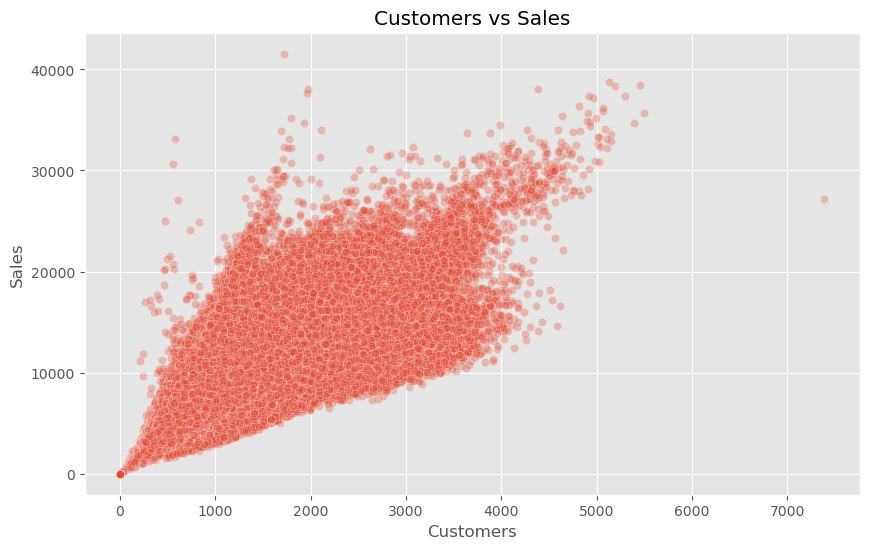

In [28]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="Customers",
    y="Sales",
    data=df,
    alpha=0.3
)

plt.title("Customers vs Sales")

plt.show()

**EDA Conclusion**

The scatter plot shows a strong positive relationship between the number of customers and sales, indicating that stores with more customers generally generate higher revenue. However, the relationship is not perfectly linear, as sales vary for similar customer counts due to factors such as promotions, store type, holidays, and average basket size. A few outliers are also visible, representing days with exceptionally high sales or customer counts. Overall, the Customers feature appears to be one of the strongest predictors of Sales and is expected to be highly important in a forecasting model.

**Correlation Heatmap**

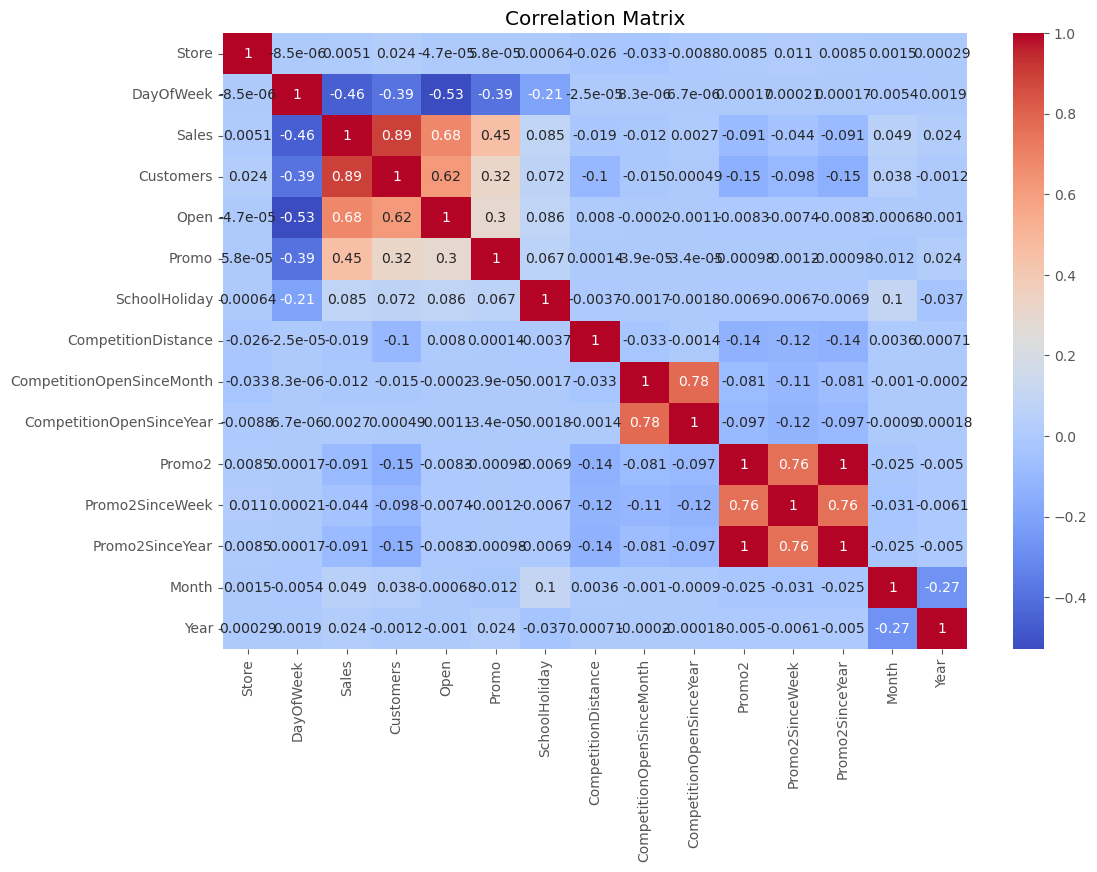

In [30]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

| Feature             | Correlation with Sales | Strength          |
| ------------------- | ---------------------: | ----------------- |
| Customers           |               **0.89** | Very Strong      |
| Open                |               **0.68** | Strong         |
| Promo               |               **0.45** | Moderate        |
| DayOfWeek           |              **-0.46** | Moderate Negative |
| SchoolHoliday       |              **0.085** | Very Weak         |
| CompetitionDistance |             **-0.019** | Negligible        |


**Holiday Analysis**

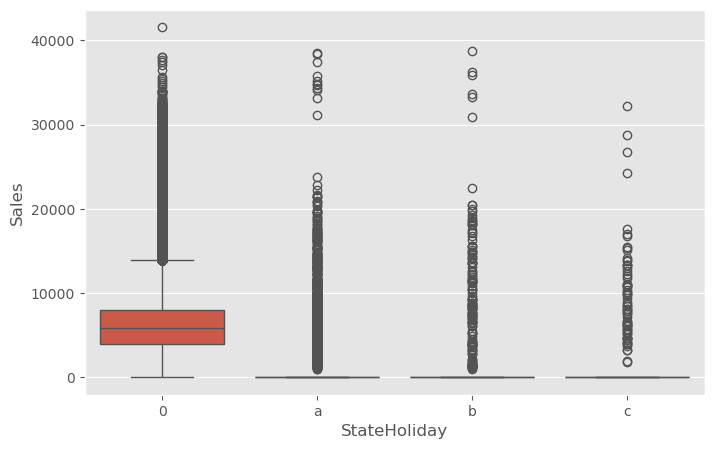

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="StateHoliday",
    y="Sales",
    data=df
)

plt.show()

Business Insight

State holidays generally lead to store closures and zero sales.

However, a few stores continue operating, producing the outliers visible in the plot.

This suggests StateHoliday is an important feature for predicting sales.

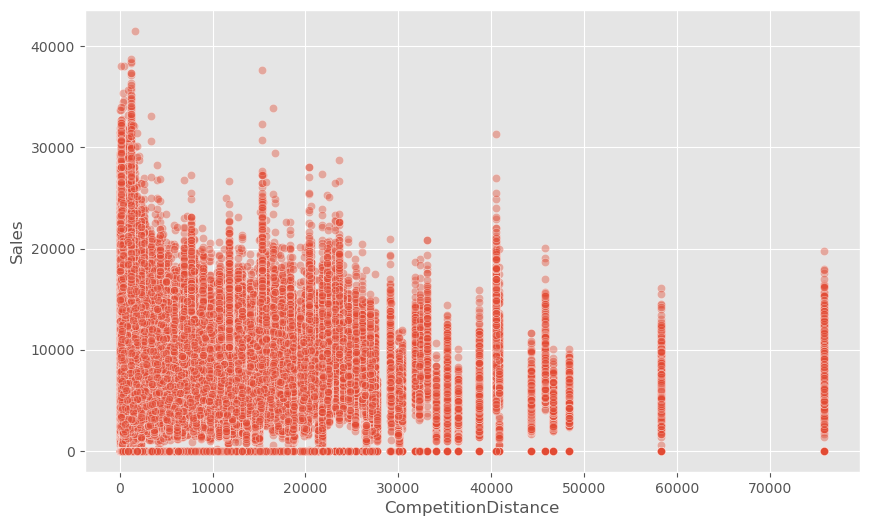

In [32]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="CompetitionDistance",
    y="Sales",
    data=df,
    alpha=0.4
)

plt.show()

**Business Insight**

One might expect that stores farther from competitors would have higher sales due to less competition. However, this plot does not support that assumption.

Possible reasons:

Store size matters more.
Promotions have a stronger effect.
Customer traffic is more important.
Store type influences sales.
Local demographics play a larger role.

In [33]:
df.groupby("Open")["Sales"].mean()

Open
0       0.000000
1    6955.514291
Name: Sales, dtype: float64

<Axes: xlabel='Open', ylabel='Sales'>

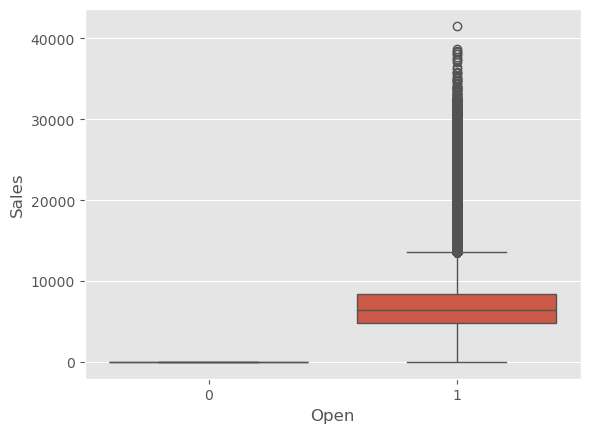

In [34]:
sns.boxplot(
    x="Open",
    y="Sales",
    data=df
)

**EDA Interpretation**

The box plot demonstrates that store opening status has a significant impact on sales. Stores that are closed (Open = 0) consistently record zero sales, resulting in a collapsed box plot at zero. In contrast, open stores (Open = 1) exhibit a median sales value of approximately 6,000, with the middle 50% of sales ranging from roughly 5,000 to 8,000. Numerous high-value outliers indicate occasional peak sales days. Overall, Open is one of the strongest predictors of sales and should be included as a key feature in any sales forecasting model.

<Axes: xlabel='Store'>

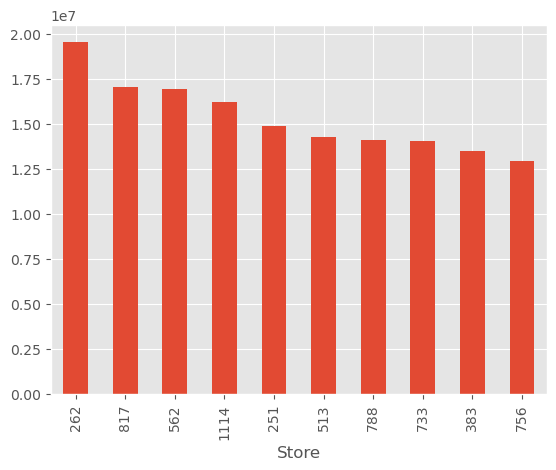

In [35]:
top_store = (
    df.groupby("Store")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_store.plot(kind="bar")

**EDA Interpretation**

The bar chart displays the top 10 stores by total sales. Store 262 recorded the highest cumulative sales (approximately 19.5 million), followed by Stores 817 and 562. Although all top-performing stores generated substantial revenue, there is a noticeable gap between the highest- and lowest-ranked stores in the top 10. This suggests that store-specific factors such as location, customer volume, promotions, and assortment may significantly influence overall sales performance. Analyzing these high-performing stores can provide valuable insights for improving sales across other stores.

<Axes: xlabel='Store'>

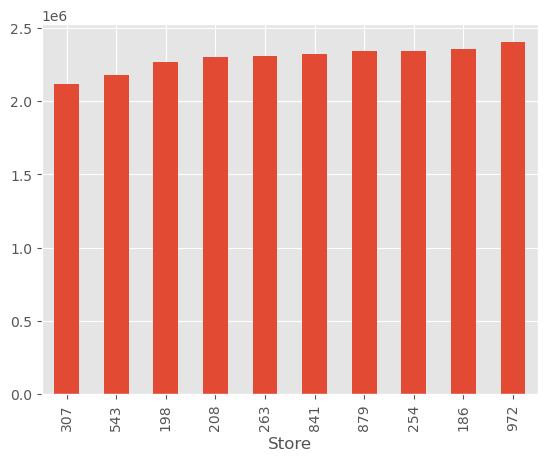

In [36]:
top_store = (
    df.groupby("Store")["Sales"]
      .sum()
      .sort_values(ascending=True)
      .head(10)
)

top_store.plot(kind="bar")

<Axes: xlabel='StoreType', ylabel='count'>

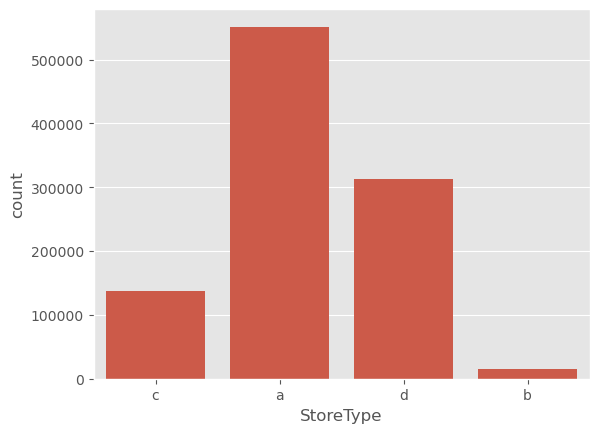

In [39]:
sns.countplot(
    x="StoreType",
    data=df
)

**Assortment analysis**

<Axes: xlabel='Assortment', ylabel='Sales'>

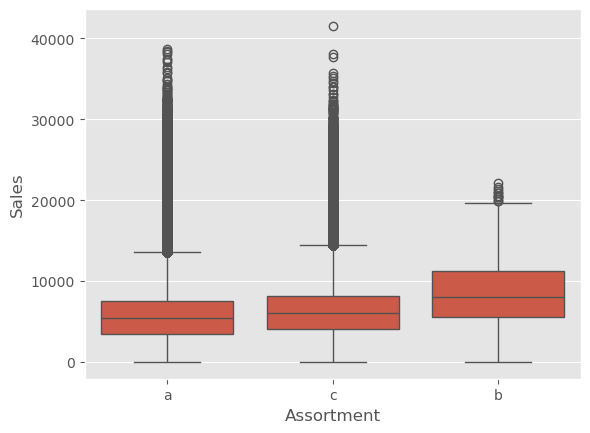

In [38]:
sns.boxplot(
    x="Assortment",
    y="Sales",
    data=df
)

**Promo2 Analysis**

<Axes: xlabel='Promo2', ylabel='Sales'>

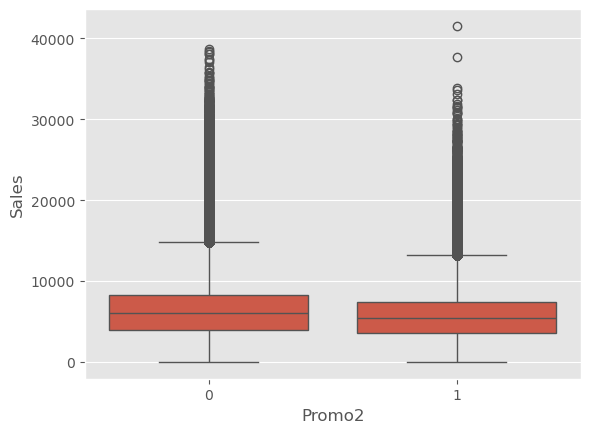

In [40]:
sns.boxplot(
    x="Promo2",
    y="Sales",
    data=df
)

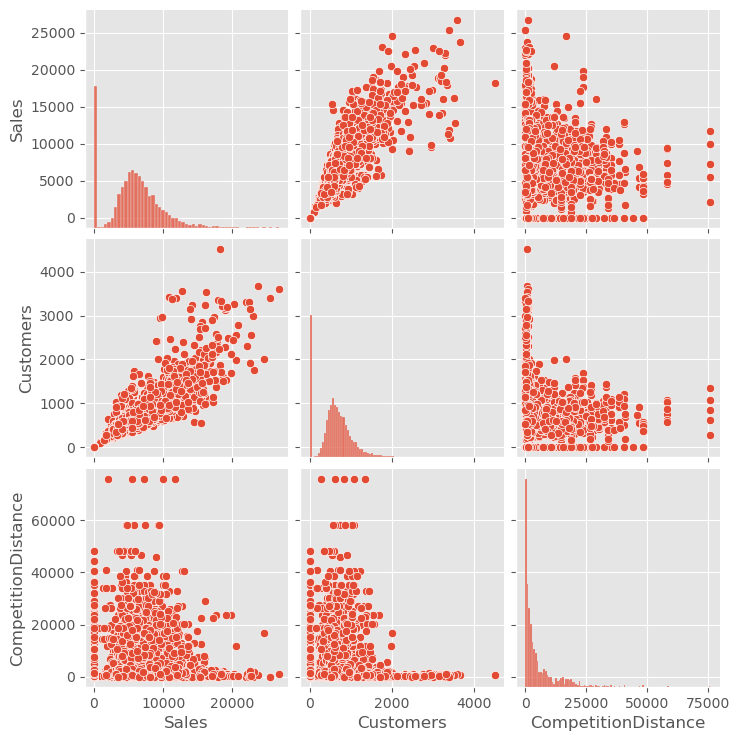

In [41]:
sample_df = df.sample(5000, random_state=42)

sns.pairplot(
    sample_df[
        [
            "Sales",
            "Customers",
            "CompetitionDistance"
        ]
    ]
)

**A pair plot is a visualization that displays the distribution of individual numerical variables on the diagonal and scatter plots showing pairwise relationships between variables on the off-diagonal. It is commonly used in Exploratory Data Analysis (EDA) to identify correlations, patterns, clusters, and outliers.**

In [42]:
df.isnull().sum()

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance               0
CompetitionOpenSinceMonth         0
CompetitionOpenSinceYear          0
Promo2                            0
Promo2SinceWeek                   0
Promo2SinceYear                   0
PromoInterval                508031
Month                             0
Year                              0
dtype: int64

**Key Business Insights**
 -Promotions positively impact sales. Stores running promotions (Promo = 1) have a higher median sales value than stores without promotions, indicating that promotional campaigns effectively boost sales.
 -Customer count is the strongest predictor of sales. The scatter plot and correlation matrix show a strong positive relationship between Customers and Sales (correlation ≈ 0.89), meaning stores with more customers generally generate higher revenue.
Store Type B consistently outperforms other store types. The box plot shows that Store Type B has the highest median sales and the widest sales distribution, indicating superior overall performance.
 -Store assortment influences sales performance. Stores with Assortment Type B (Extra Assortment) exhibit higher median sales compared to Assortment Types A and C, suggesting that a broader product selection contributes to increased revenue.
Store opening status has a significant impact on sales. Stores that are closed (Open = 0) consistently report zero sales, while open stores generate substantial revenue. This confirms the consistency of the dataset and highlights Open as an important feature.
 -State holidays significantly reduce sales. Stores generally record zero sales during state holidays (StateHoliday = a, b, c), indicating that many stores remain closed on these days.
 -Competition distance has a negligible relationship with sales. Both the scatter plot and correlation matrix (correlation ≈ -0.02) indicate that the distance to the nearest competitor has little influence on store sales when analyzed independently.
 -Promo2 shows limited impact on sales. The sales distributions for stores participating and not participating in the long-term --Promo2 program are very similar, suggesting that Promo2 alone is not a strong predictor of sales.
 -Sales data contains several high-value outliers. Box plots reveal numerous unusually high sales observations, likely corresponding to promotions, festive seasons, or high-performing stores.
 -Most numerical variables are positively skewed. Histograms in the pair plot indicate that Sales, Customers, and CompetitionDistance have right-skewed distributions, with most observations concentrated at lower values and a few extreme values.